In [1]:
from pinnsform.util import *
from pinnsform.model import PINNsformer
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

def load_csv_to_numpy(file_path):
    df = pd.read_csv(file_path, header=None, index_col=None, sep=",")
    return np.array(df.values)

def load_csv_series(path):
    label_and_data = load_csv_to_numpy(path)
    labels = list(label_and_data[0])
    data = label_and_data.T[:,1:].astype(float)
    return labels, data

In [78]:
def plot_evolution(
    value_evolution,
    evolution_label,
    title="Training loss evolution",
    xlabel="# epochs",
    ylabel="loss",
    linestyle='solid',
):
    fig, ax = plt.subplots()
    if isinstance(evolution_label, list):
        if len(value_evolution) != len(evolution_label):
            raise ValueError("The number of value evolutions and labels must match.")
        for i, evo in enumerate(value_evolution):
            ax.semilogy(evo, label=evolution_label[i], linestyle=linestyle)
    else:
        ax.semilogy(value_evolution, label=evolution_label)
    ax.set(title=title, xlabel=xlabel, ylabel=ylabel)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.05))
    ax.legend()

def param_vector(model):
    all_params = []
    for param in model.parameters():
        all_params.append(param.data.numpy().flatten())
    return np.concatenate(all_params)

def visualize_solution(model, mesh, mesh_shape, domain):
    prediction = f(model, mesh)[:,0].detach().cpu().numpy()
    predicted_mesh = np.reshape(prediction, mesh_shape)
    #[0,np.pi*2,1,0]
    plt.figure(figsize=(4,3))
    domain_extend = [domain[1][0], domain[1][1], domain[0][0], domain[0][1]]
    plt.imshow(predicted_mesh, extent=domain_extend, aspect='auto',vmin=0.0, vmax=1.0)
    plt.xlabel('t')
    plt.ylabel('x')
    plt.title('Predicted u(x,t)')
    plt.colorbar()
    plt.tight_layout()
    #plt.savefig('./1dreaction_pinnsformer_pred.png')
    plt.show()
    return predicted_mesh

In [3]:
device = "cpu"
model = PINNsformer(d_out=1, d_hidden=512, d_model=32, N=1, heads=2).to(device)

In [4]:
base_dir = os.getcwd()

folder_path = os.path.join(base_dir, 'results', "Adam_PINNFORMER_TS store models", 'run', 'seed_1')

In [67]:
problem_domain = ([0, 2*np.pi], [0, 1])
test_points = (201, 201)
test_mesh, _ = generate_mesh_object(test_points, domain=problem_domain, device=device, full_requires_grad=False, border_requires_grad=False, num_seq_steps=5, seq_step_size=1e-3)

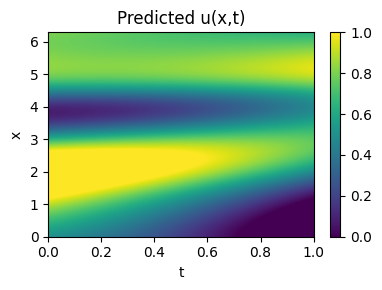

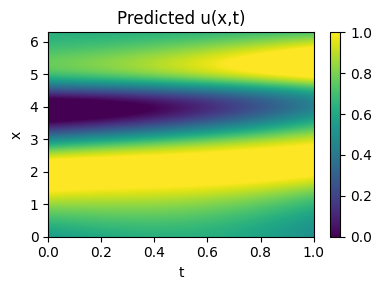

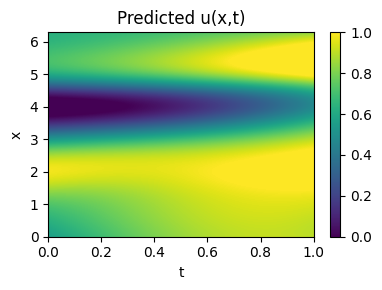

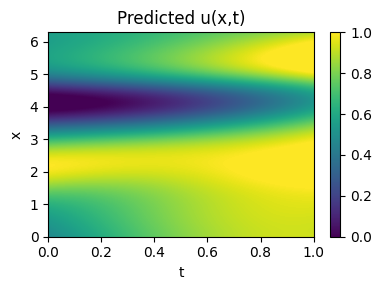

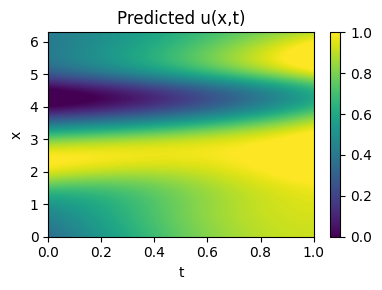

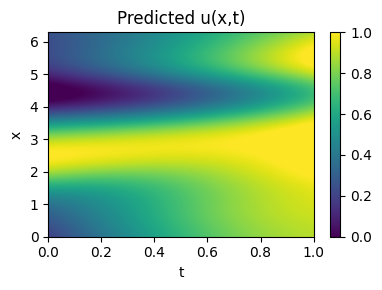

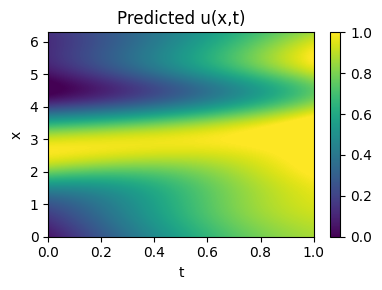

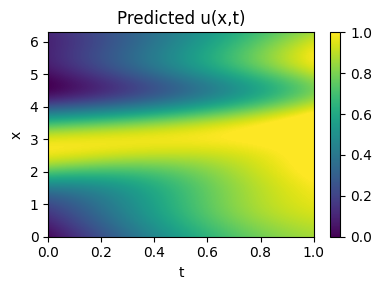

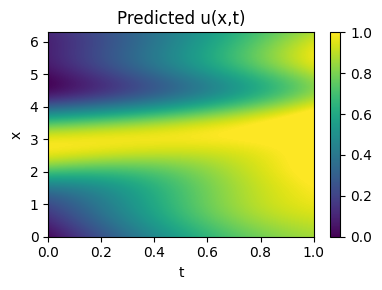

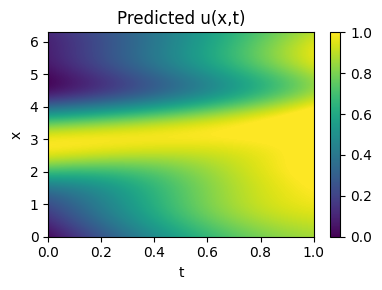

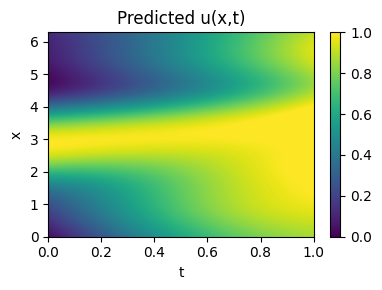

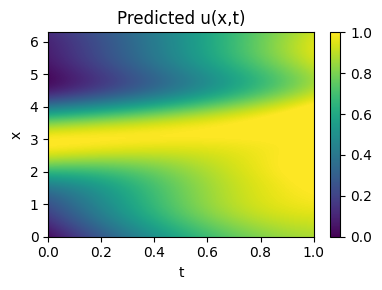

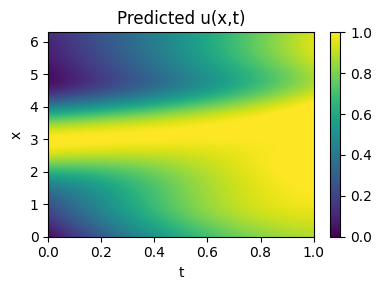

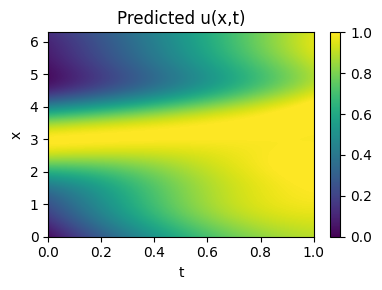

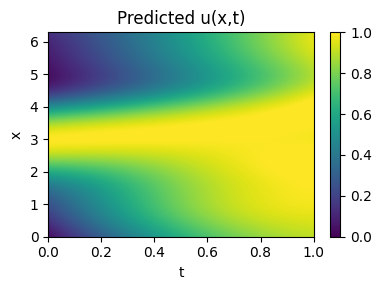

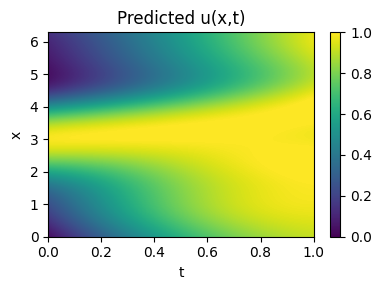

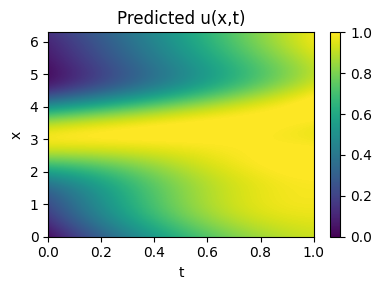

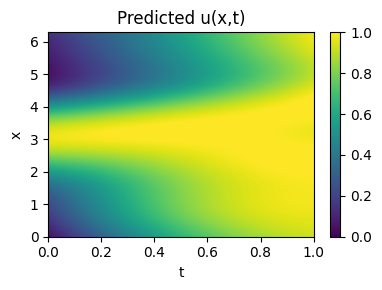

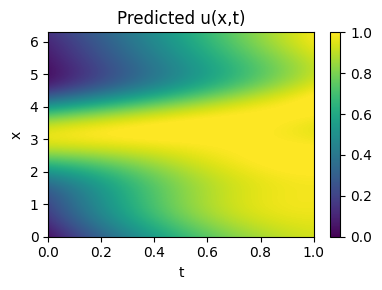

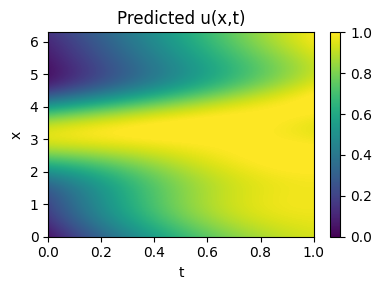

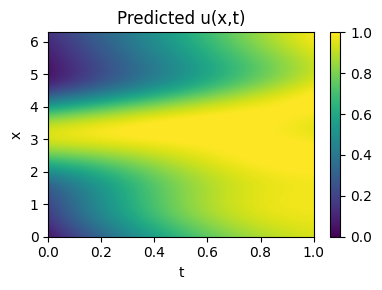

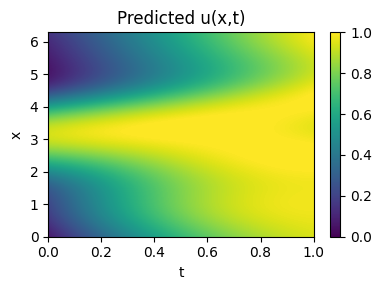

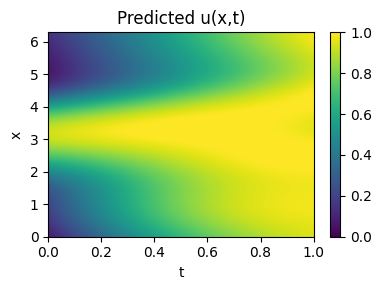

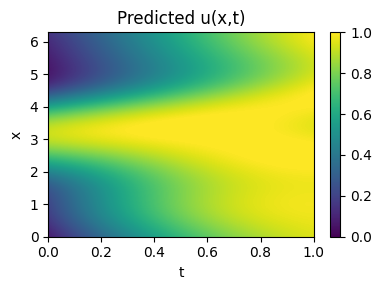

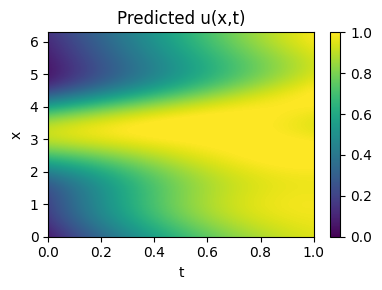

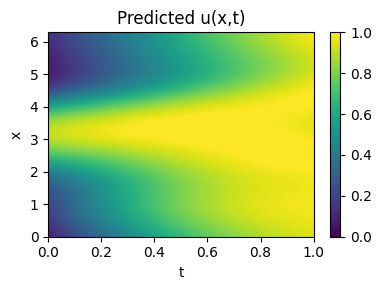

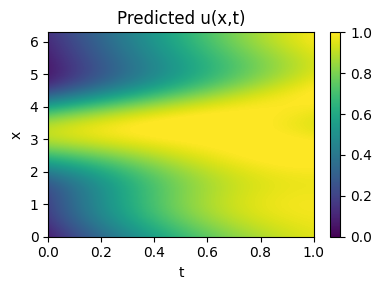

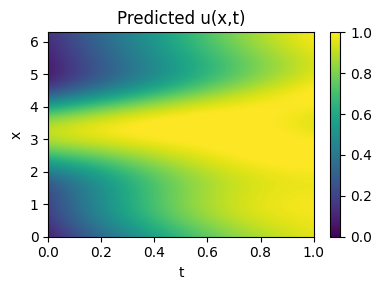

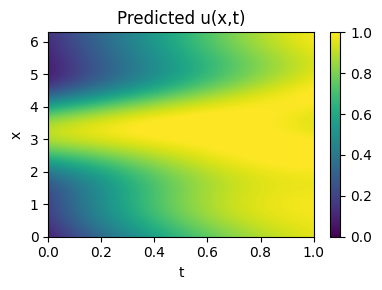

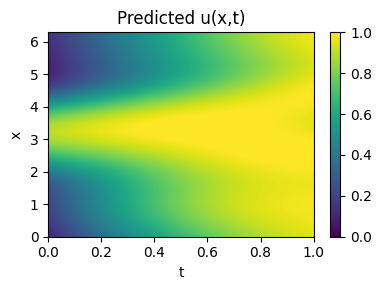

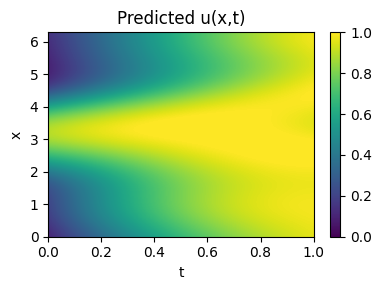

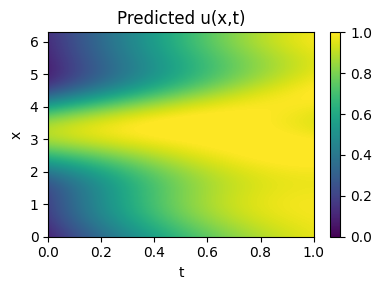

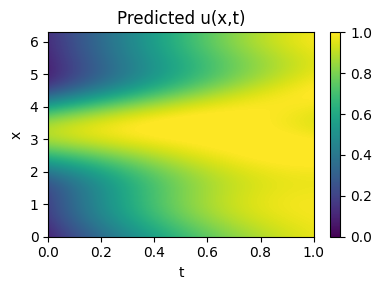

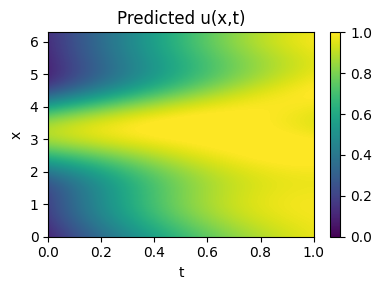

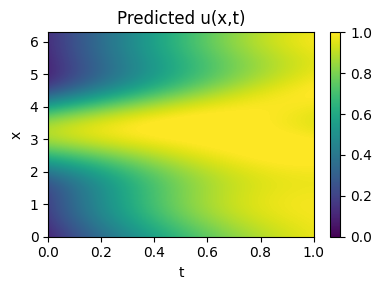

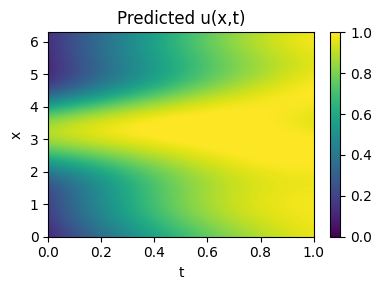

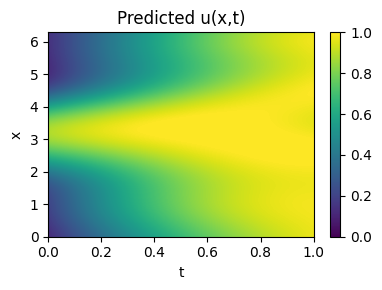

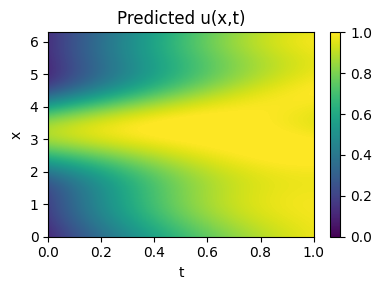

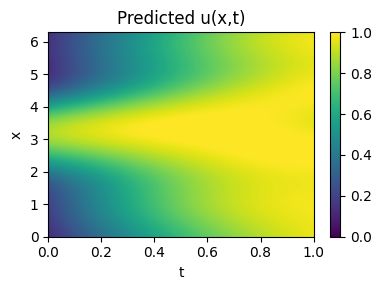

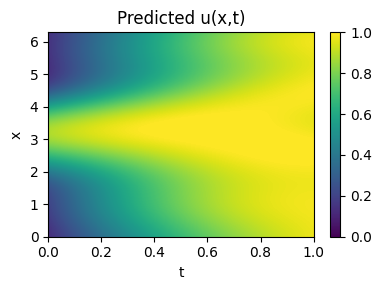

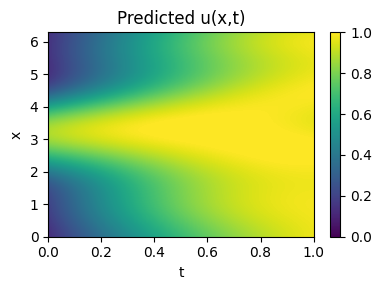

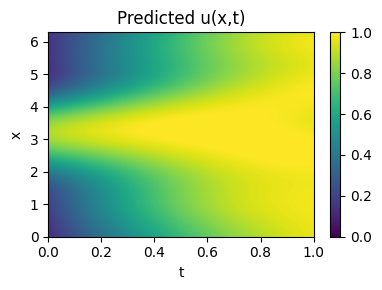

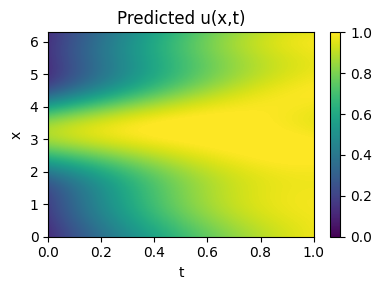

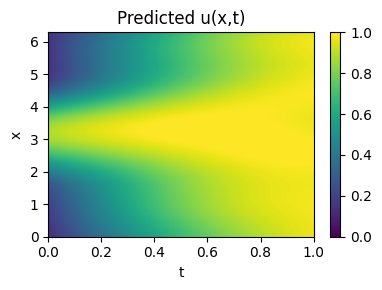

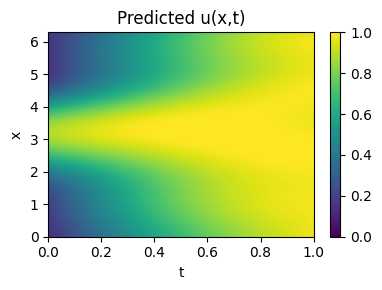

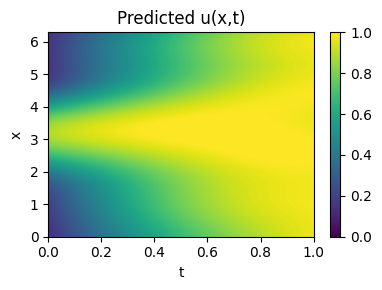

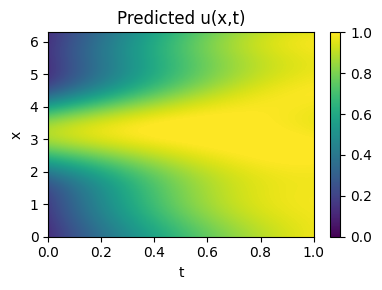

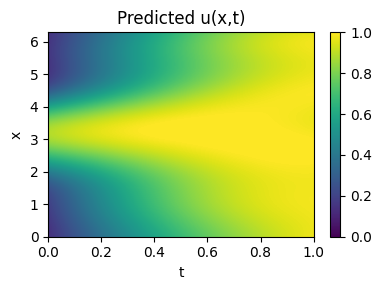

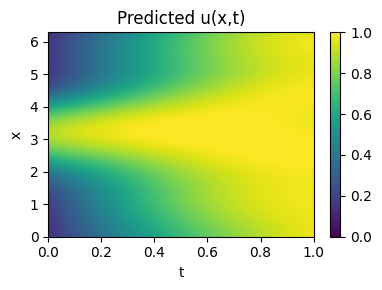

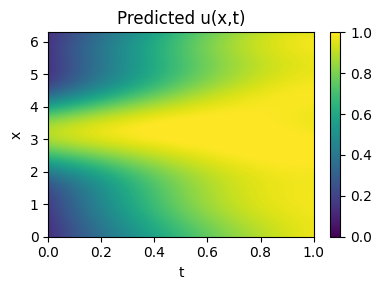

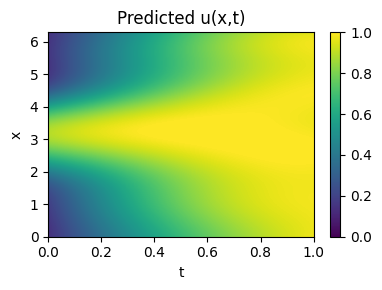

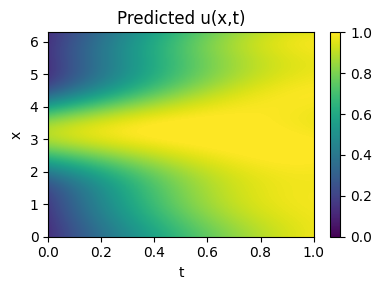

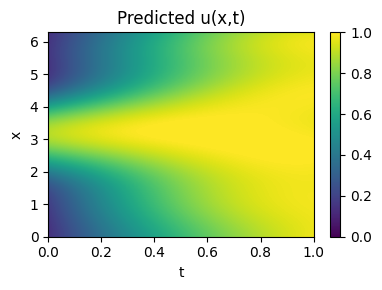

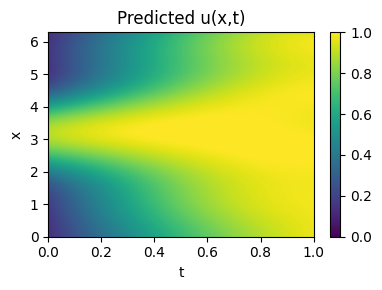

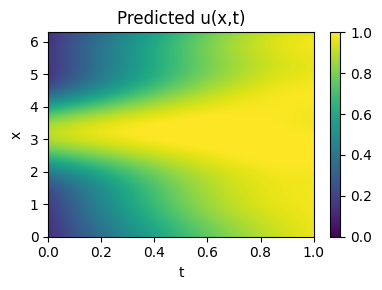

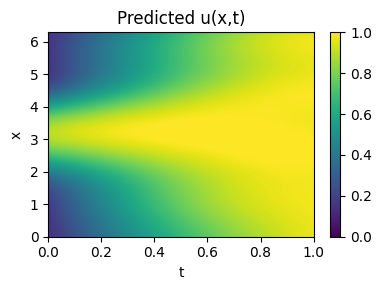

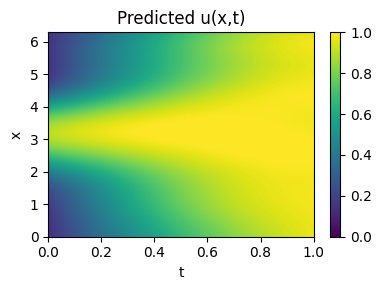

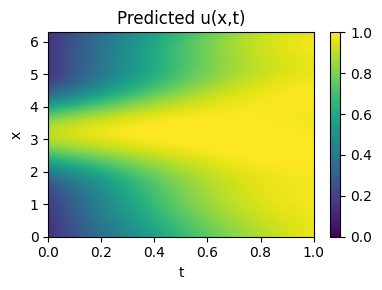

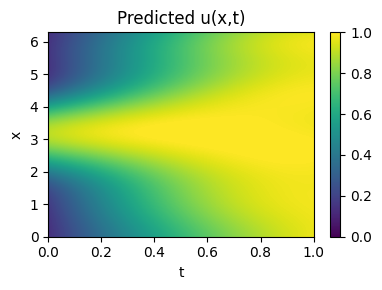

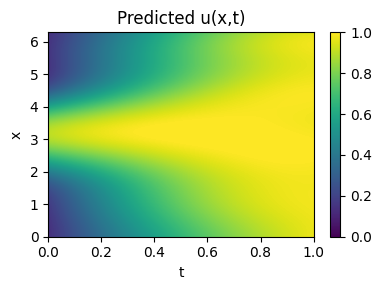

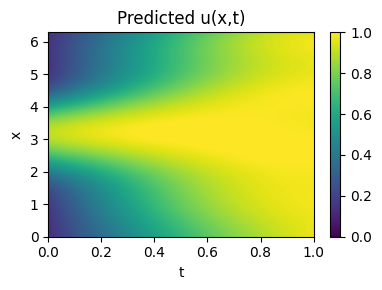

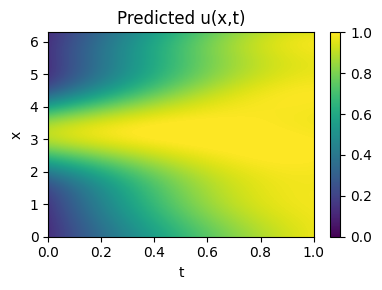

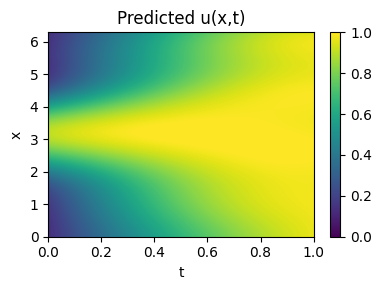

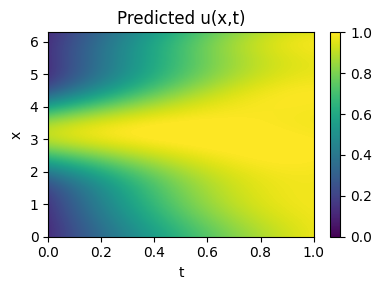

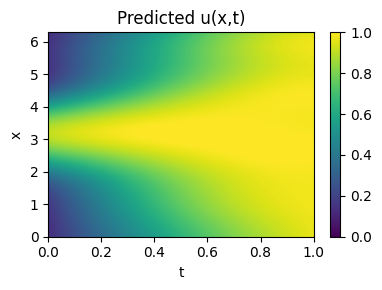

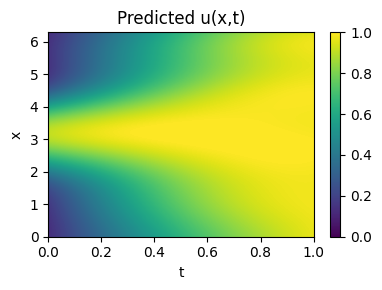

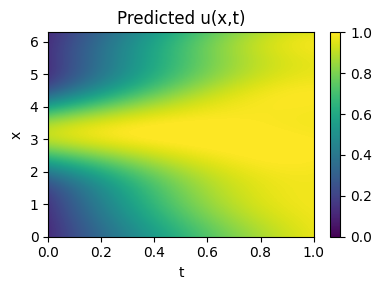

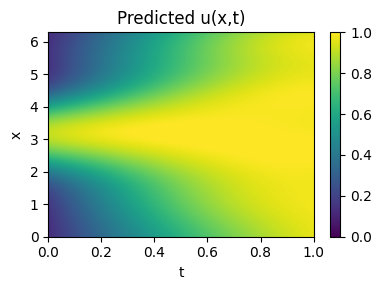

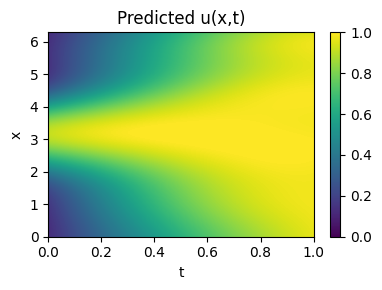

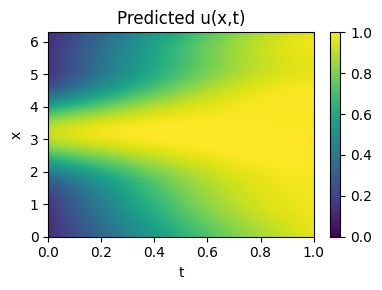

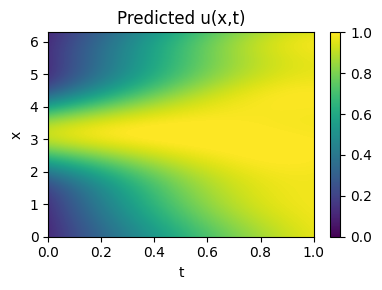

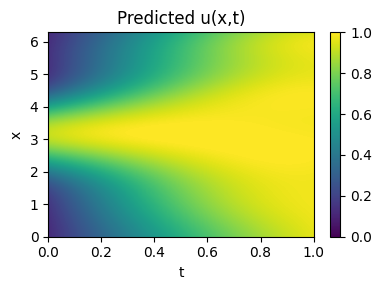

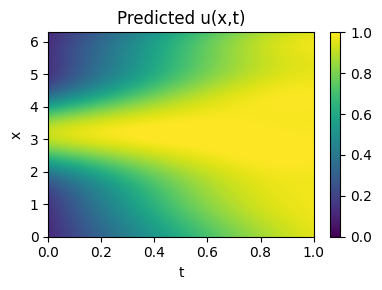

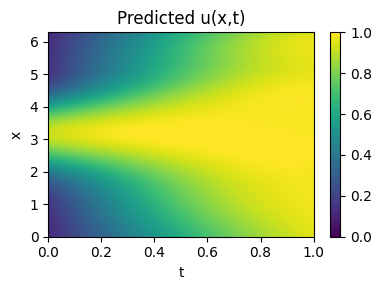

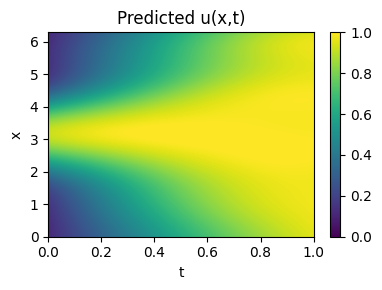

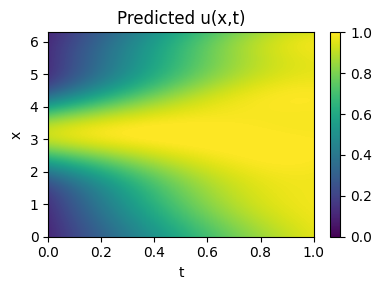

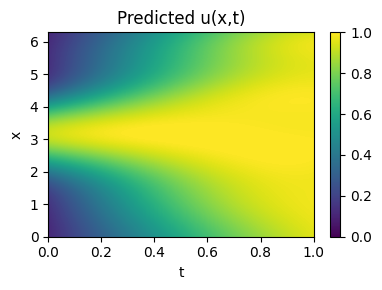

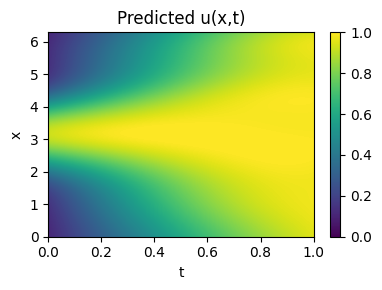

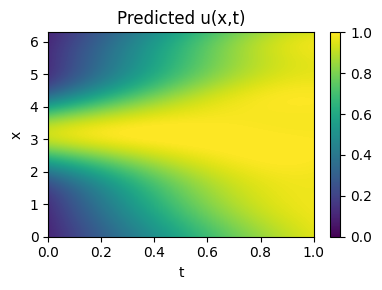

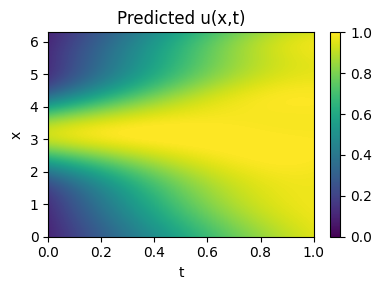

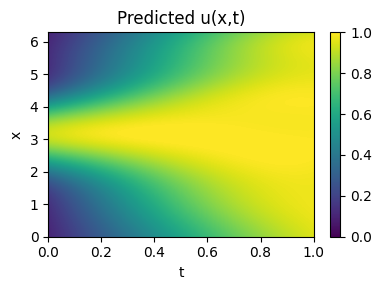

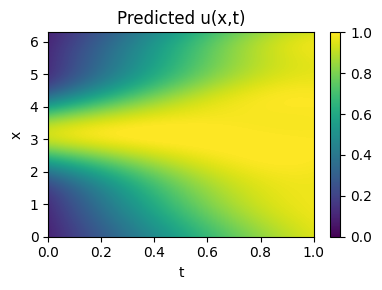

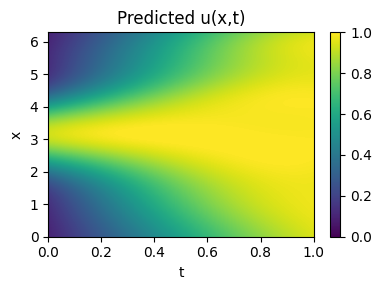

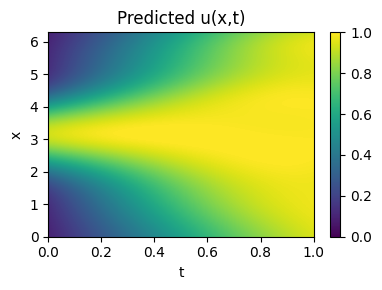

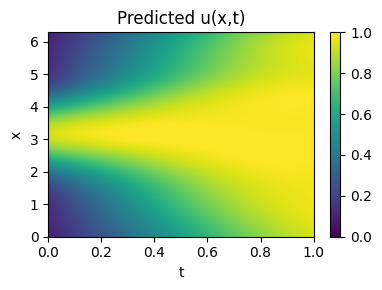

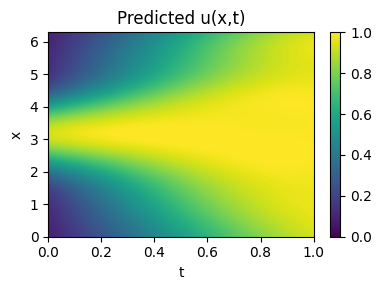

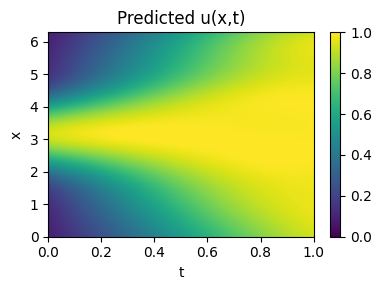

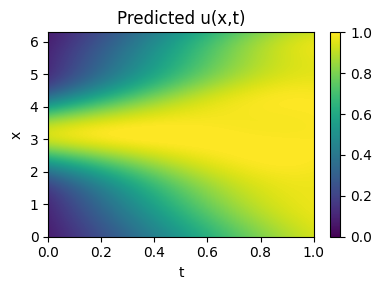

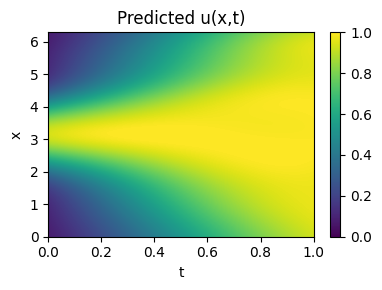

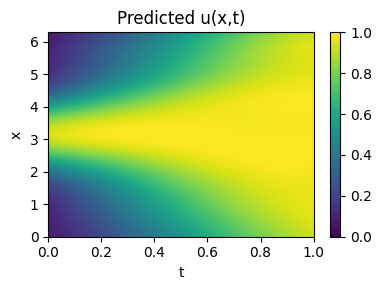

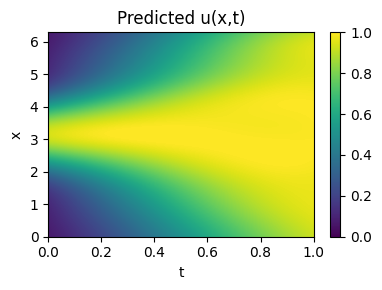

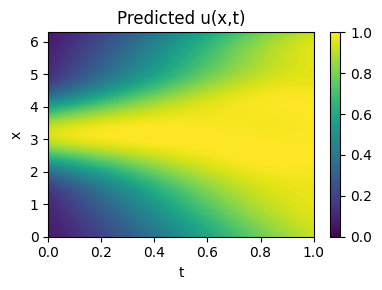

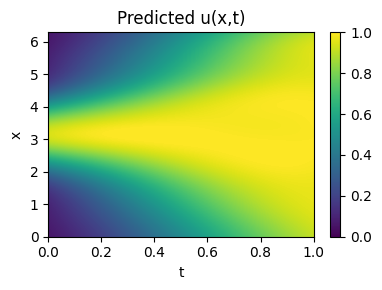

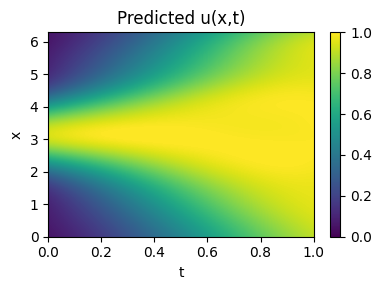

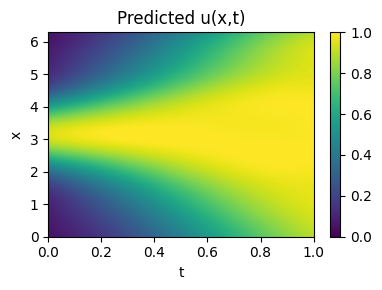

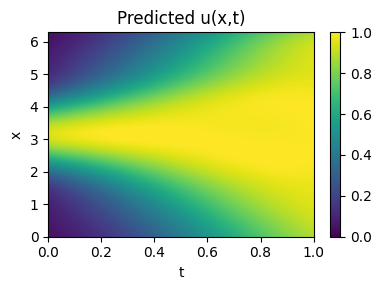

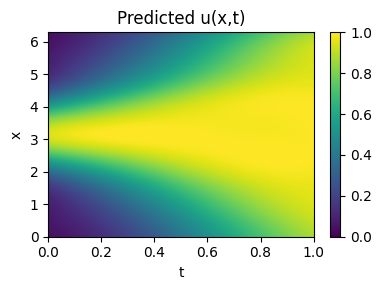

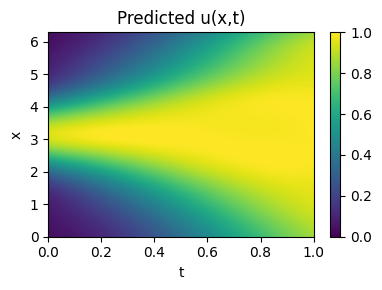

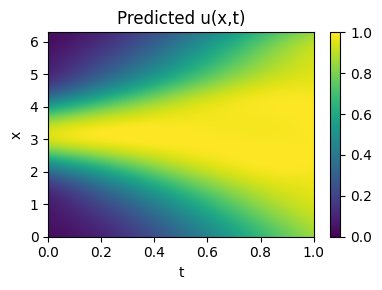

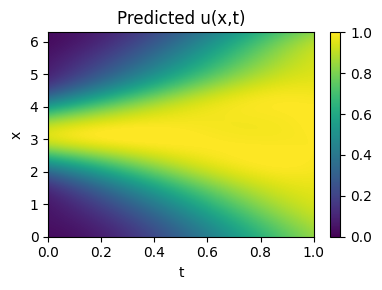

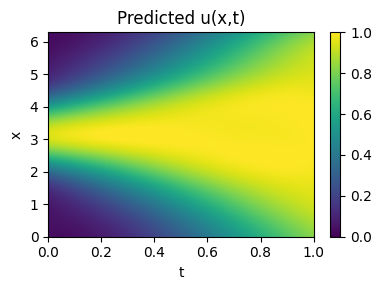

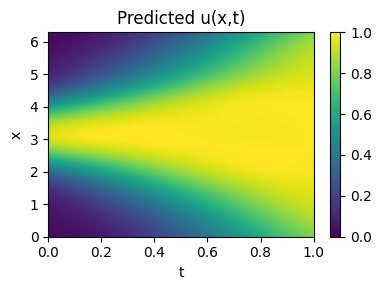

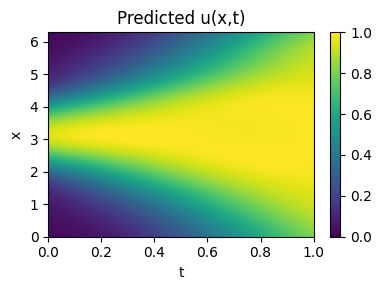

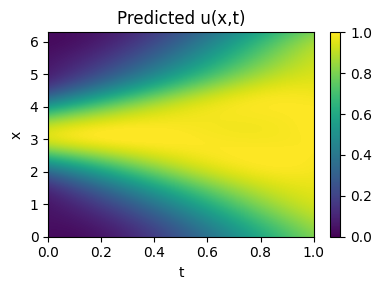

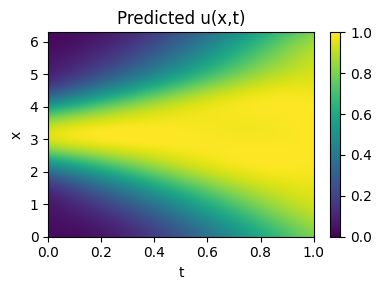

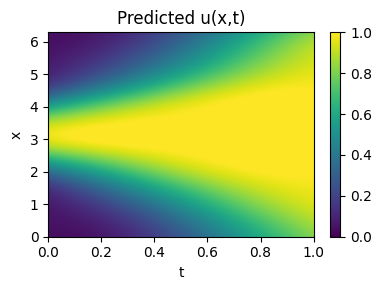

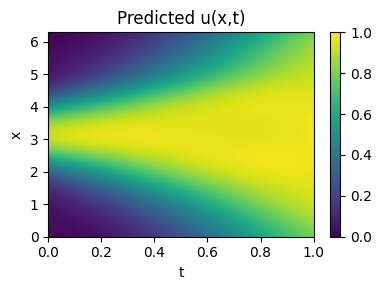

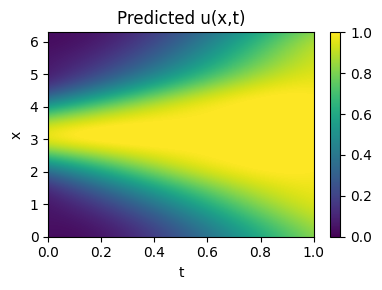

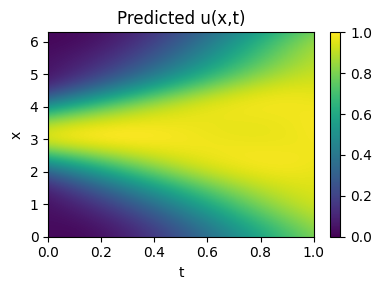

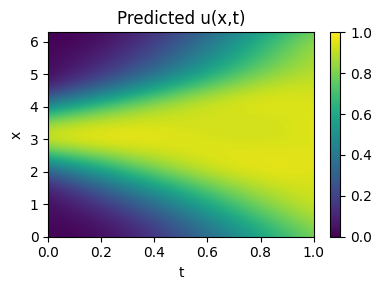

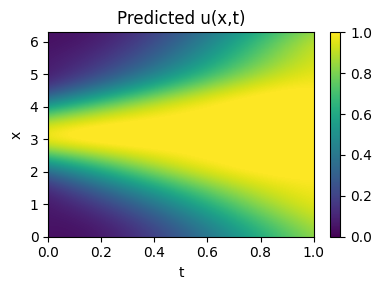

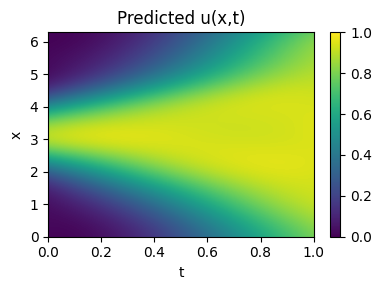

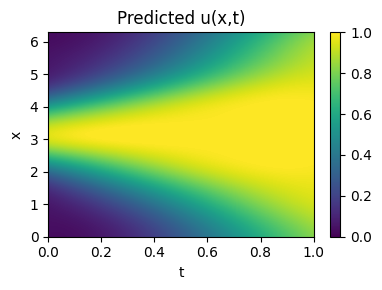

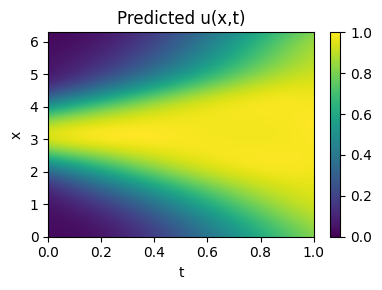

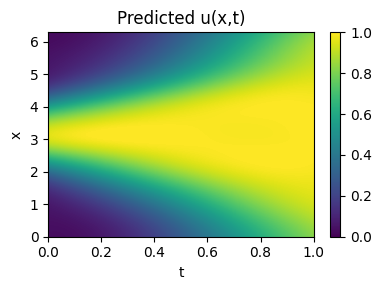

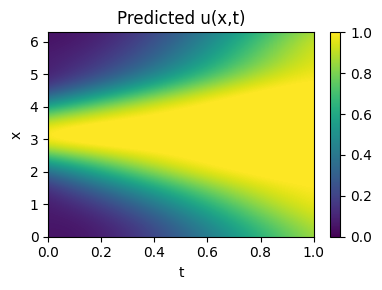

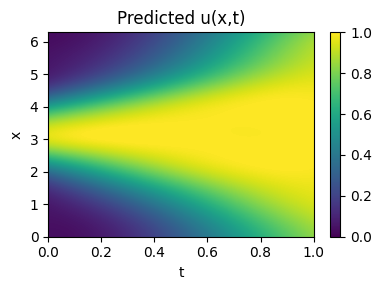

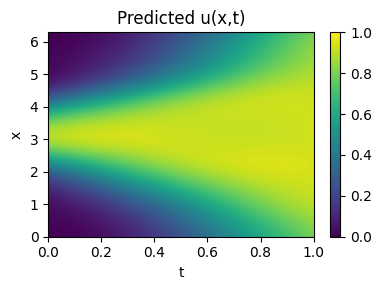

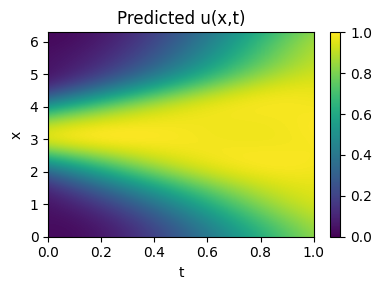

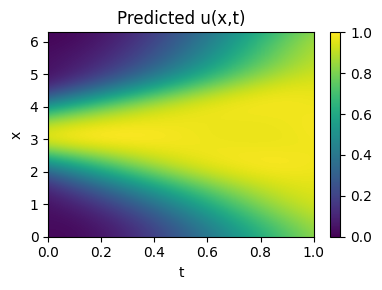

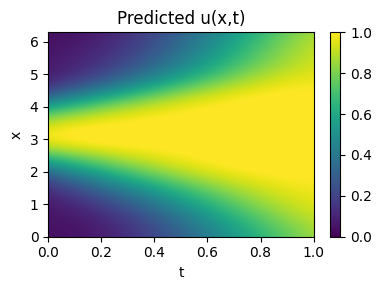

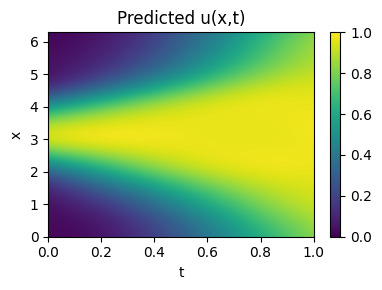

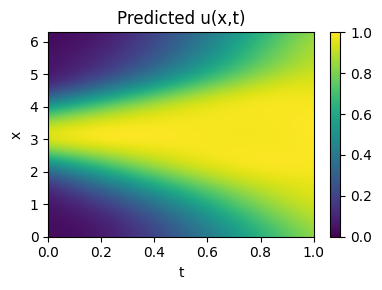

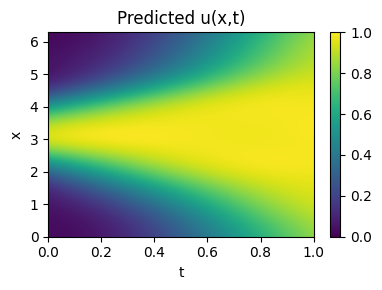

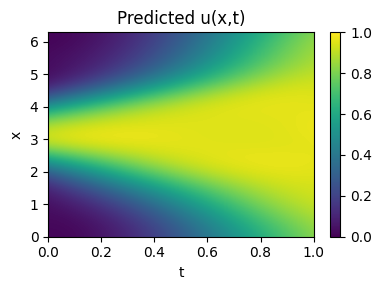

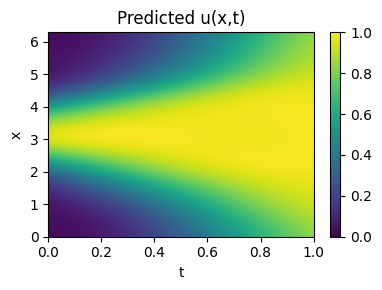

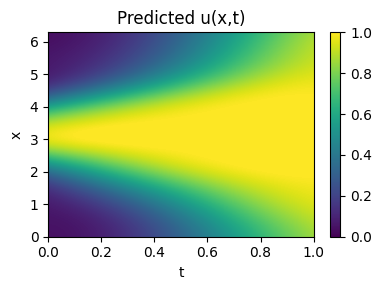

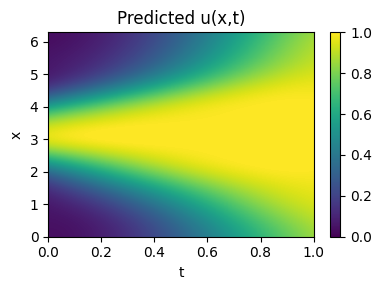

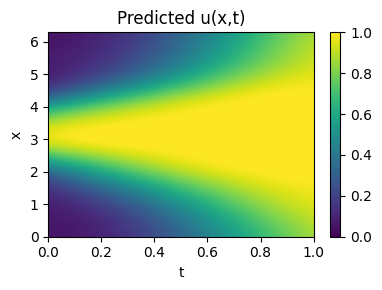

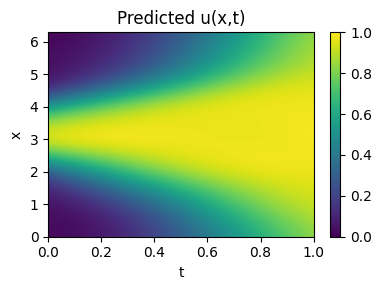

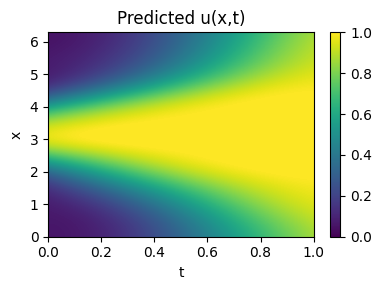

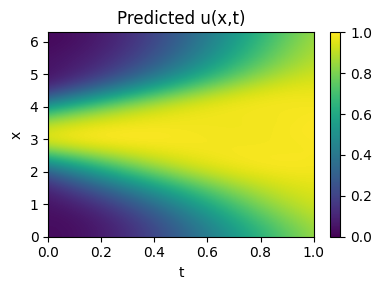

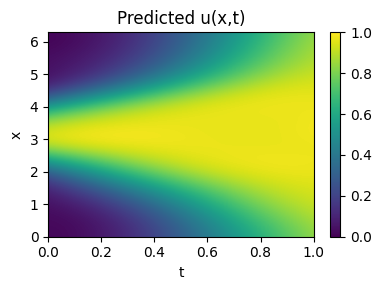

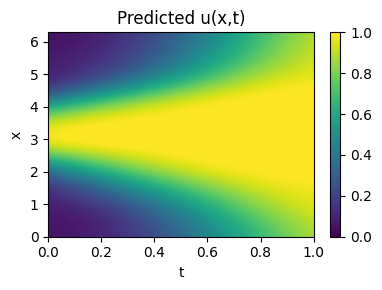

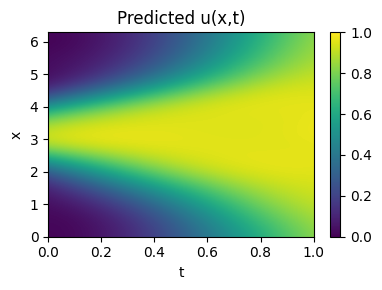

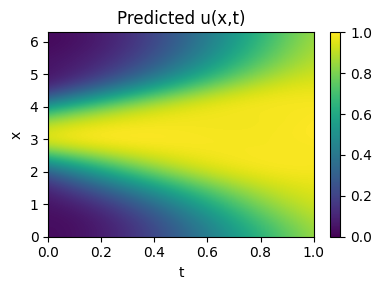

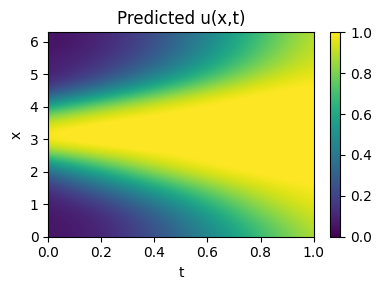

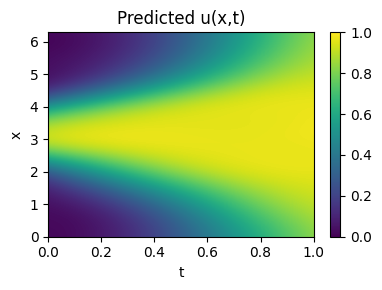

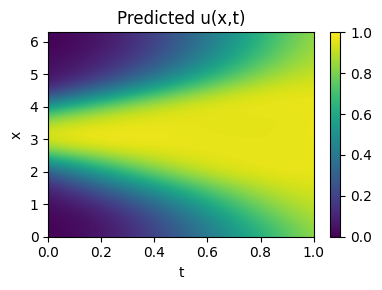

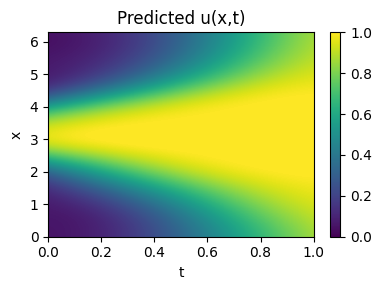

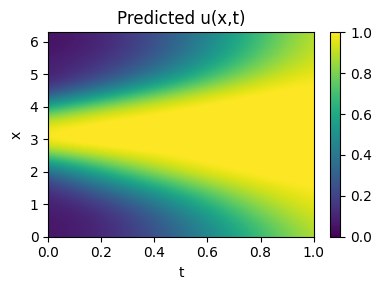

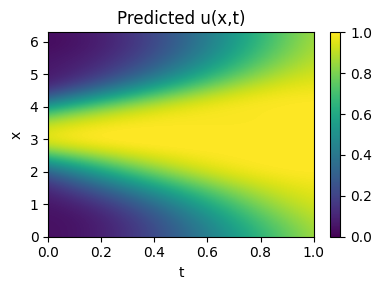

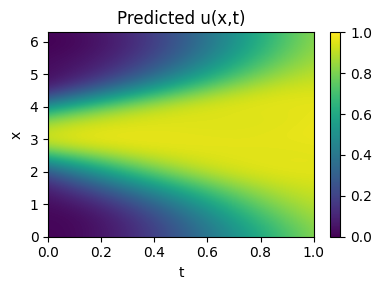

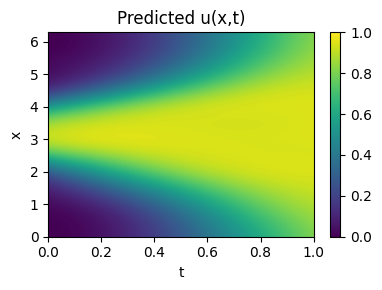

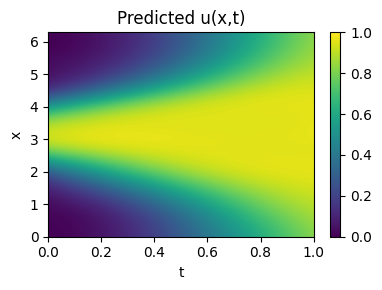

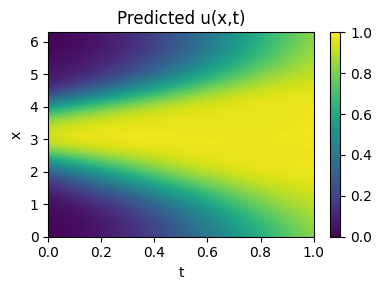

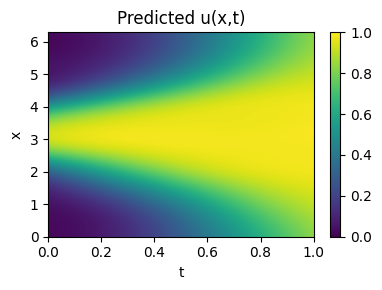

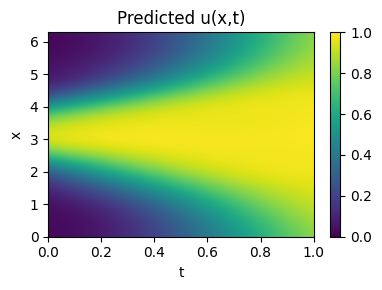

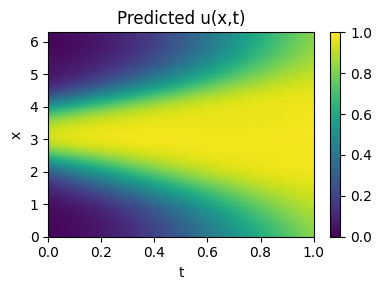

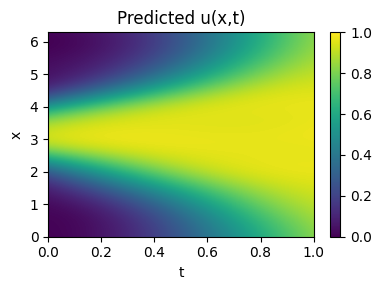

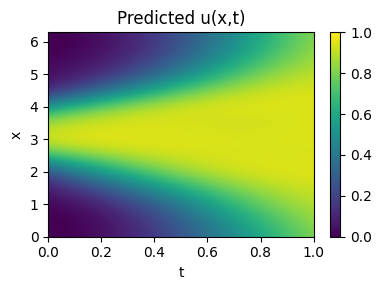

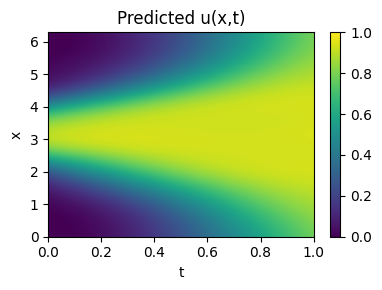

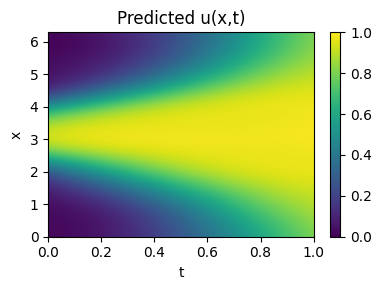

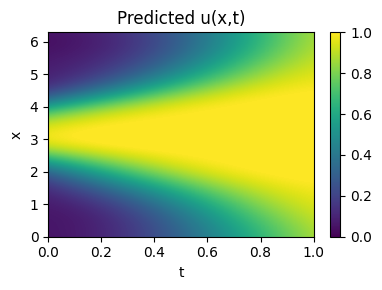

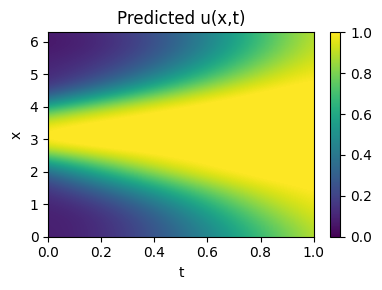

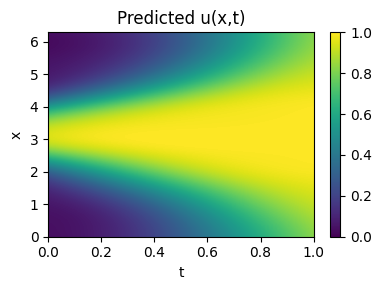

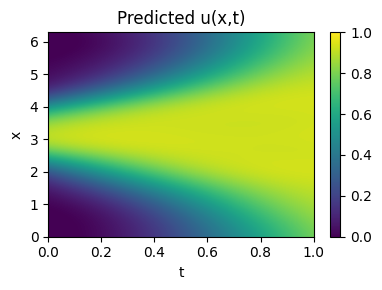

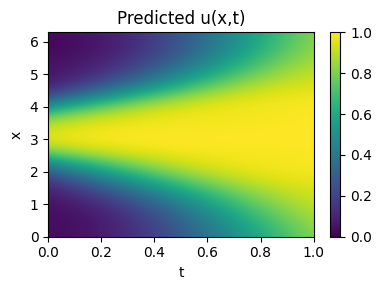

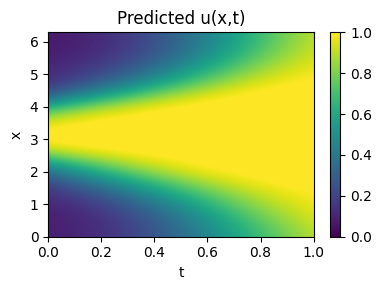

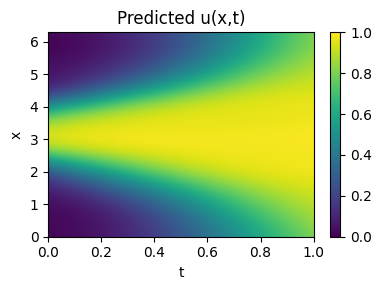

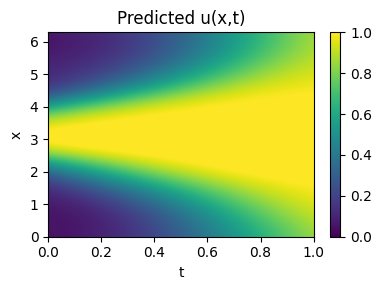

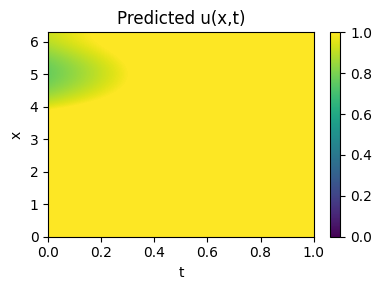

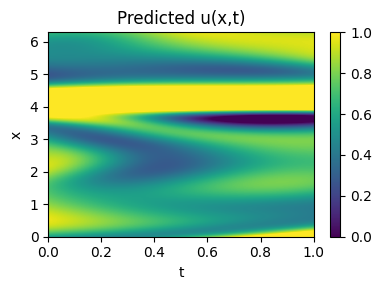

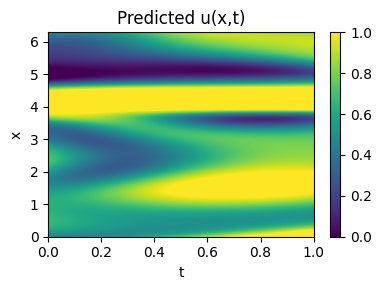

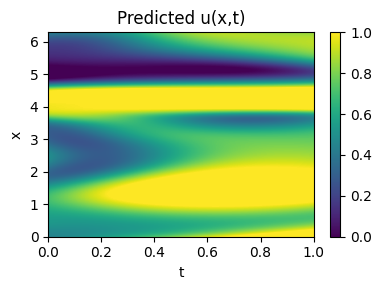

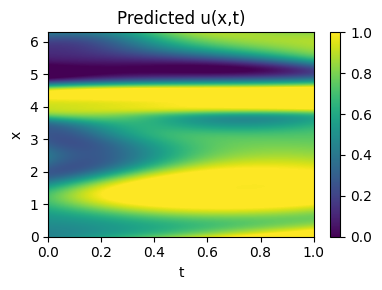

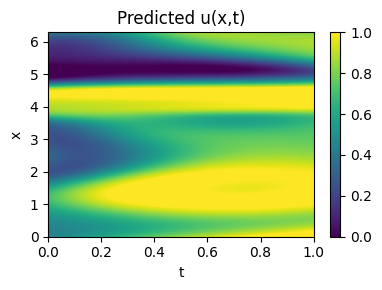

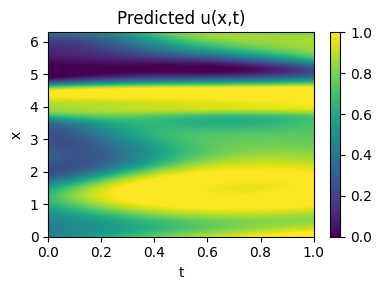

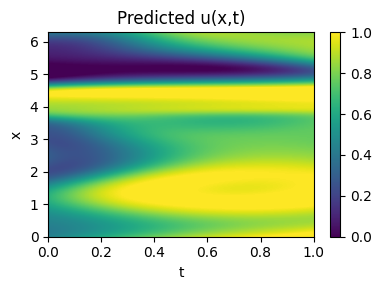

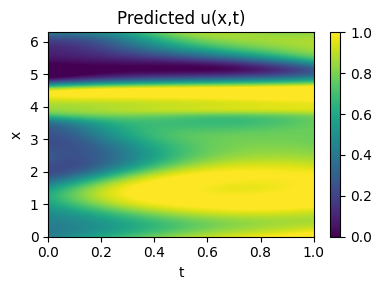

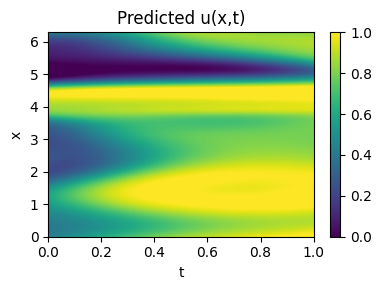

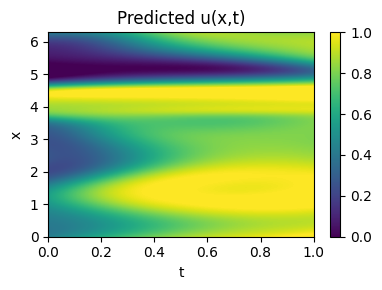

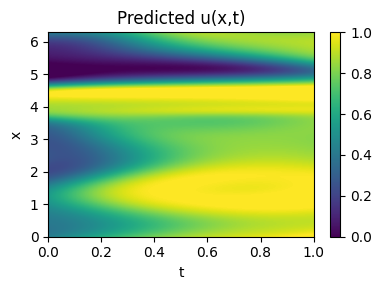

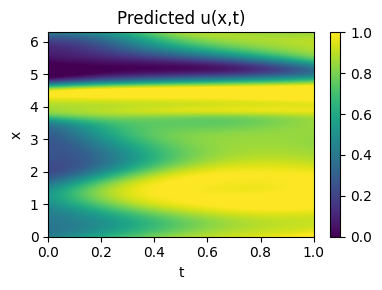

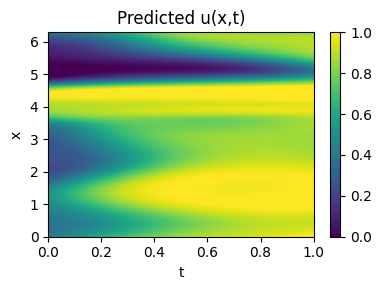

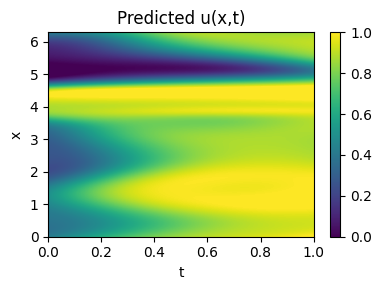

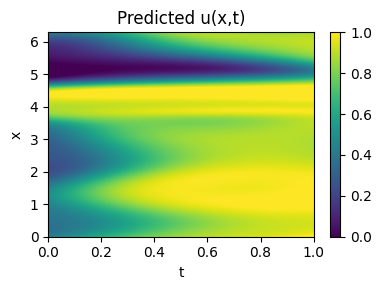

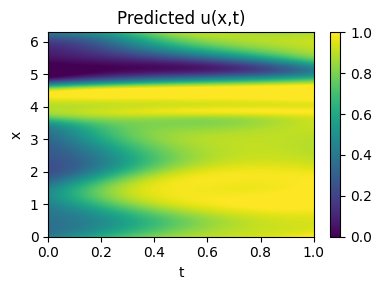

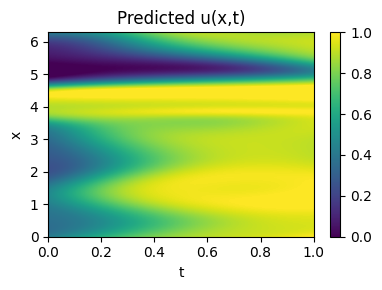

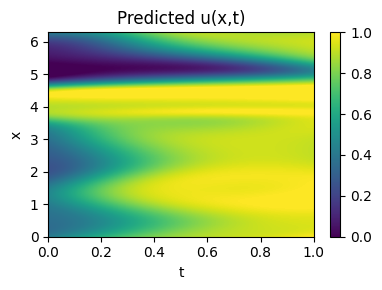

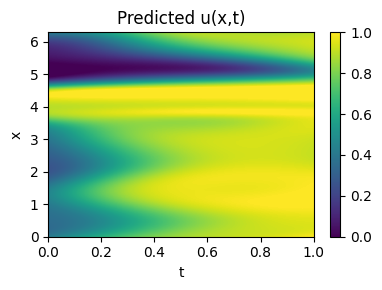

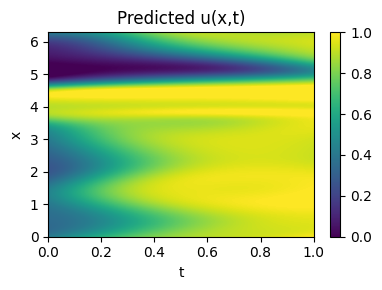

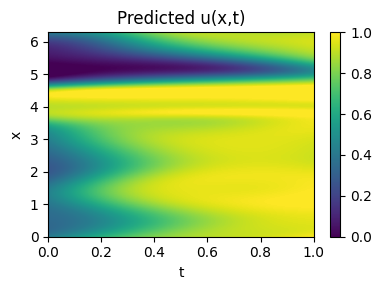

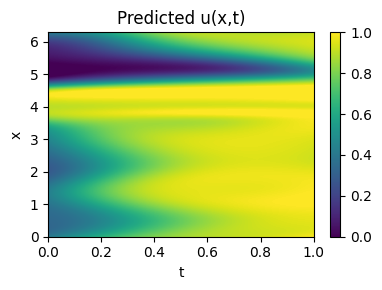

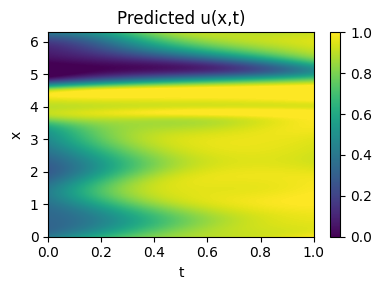

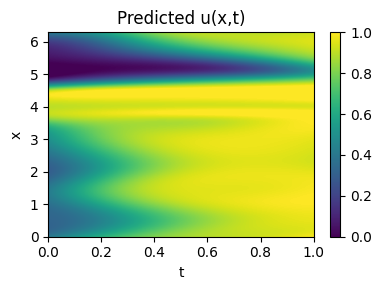

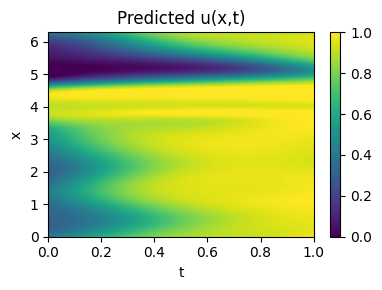

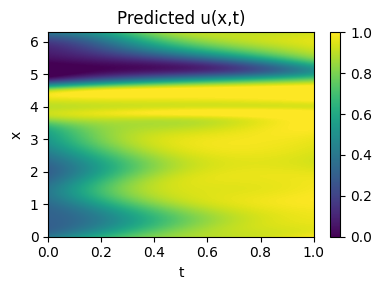

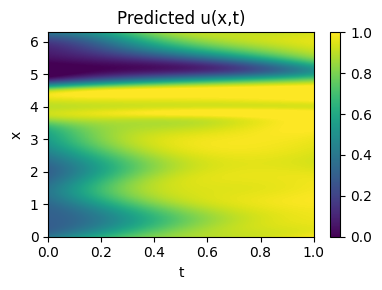

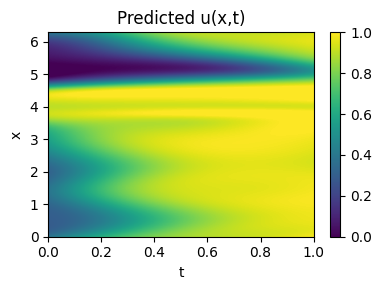

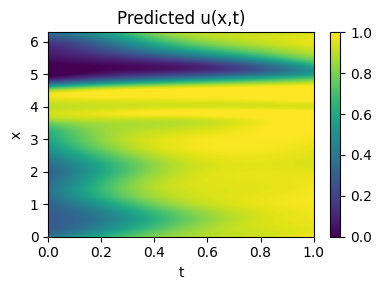

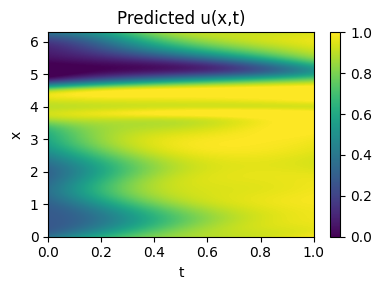

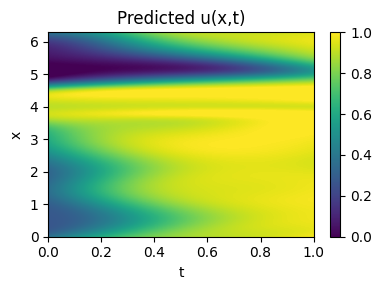

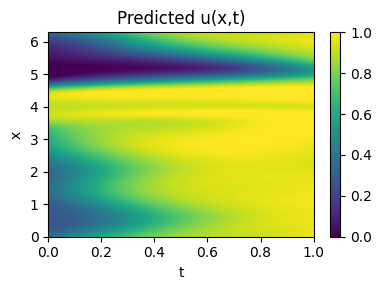

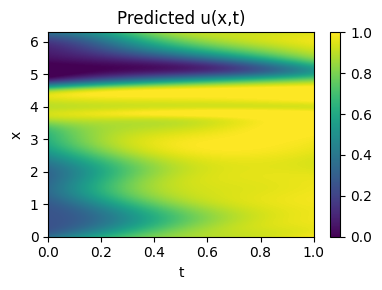

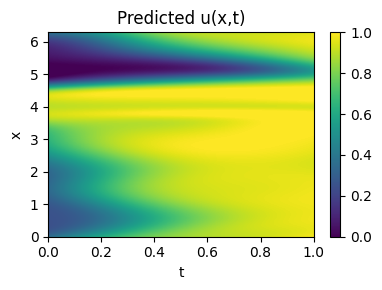

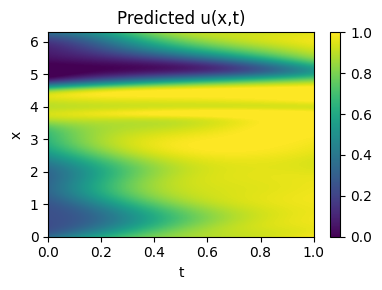

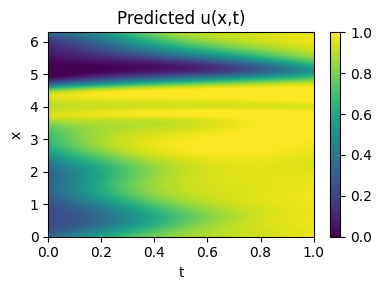

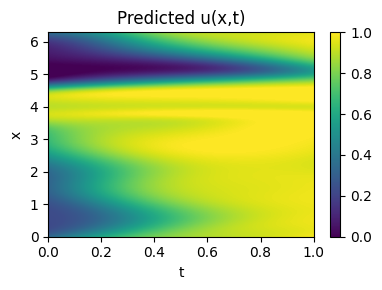

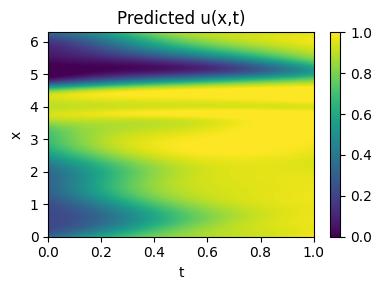

In [80]:
for i in range(1,201):
    weight_path = os.path.join(folder_path, f"model_at_{i*50 - 1}.pth")
    model.load_state_dict(torch.load(weight_path))
    visualize_solution(model, test_mesh, test_points, problem_domain)

In [70]:
weight_path = os.path.join(folder_path, 'init_model.pth')
model.load_state_dict(torch.load(weight_path))
init_params = param_vector(model)
params_list = [init_params]
for i in range(1,201):
    weight_path = os.path.join(folder_path, f"model_at_{i*50 - 1}.pth")
    model.load_state_dict(torch.load(weight_path))
    params_list.append(param_vector(model))

In [64]:
distance_to_init = []
for vector in params_list:
    distance_to_init.append(np.std(np.sqrt((init_params - vector)**2)))

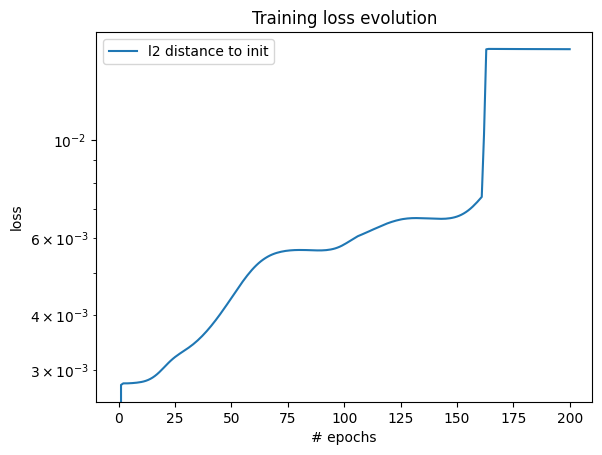

In [65]:
plot_evolution(distance_to_init, 'l2 distance to init')